# ISO 20414:2020 — Test 9: Dynamic Availability of Exit
A 10 m x 15 m room has two exits available on the 15 m walls of the room (ISO 20414:2020 Table 10). They are equally distant from the occupant spanned at the 10 m long wall at the end of the room. Exit 1 becomes unavailable after 1 s of simulation time. Expected result is that Exit 1 is not used by the occupant.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 05 August 2026, 17:07 CEST


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon

from jupedsim_scenarios import load_scenario, run_scenario, ScenarioRunner
from jupedsim_scenarios.direct_steering_runtime import pick_stage_target

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load the Scenario 

In [4]:
SCENARIO_ZIP = Path("scenario_files") / "Iso-09-dynamic-exits.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
print(scenario.summary())

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/iso/scenario_files/Iso-09-dynamic-exits.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      300s
  Exits:         2
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~1
    jps-distributions_0: 1 agents


## Run the Scenario - Exit 1 Closes after 1 s

In [5]:
EXIT_1 = "jps-exits_0"
EXIT_2 = "jps-exits_1"
def redirect_agent(runner, agent_id, exit_key):
    """Change the agent's current destination."""
    state = runner._agent_wait_info[agent_id]
    exit_config = state["stage_configs"][exit_key]

    state["current_target_stage"] = exit_key
    state["target"] = pick_stage_target(state, exit_config)
    state["target_assigned"] = False
    state["state"] = "to_target"
    state["inside_since"] = None
    state["wait_until"] = None

with ScenarioRunner(
    scenario,
    seed=42,
    every_nth_frame=1,
) as runner:
    agent = next(iter(runner.agents()))
    agent_id = agent.id

    # Both exits are initially available, but the tested occupant starts
    # by targeting Exit 1.
    redirect_agent(runner, agent_id, EXIT_1)

    # At t = 1 s, Exit 1 becomes unavailable.
    runner.run_until(1.0)
    redirect_agent(runner, agent_id, EXIT_2)

    # Continue until the occupant evacuates.
    runner.run_until()
    result = runner.result()

df = result.trajectory_dataframe()

print(f"Evacuation time: {result.evacuation_time:.2f} s")
print(f"Agents remaining: {result.agents_remaining}")

Evacuation time: 13.75 s
Agents remaining: 0


In [6]:
exit_polygons = {
    exit_id: Polygon(exit_data["coordinates"])
    for exit_id, exit_data in scenario.raw["exits"].items()
}

last_position = df.sort_values("frame").iloc[-1]
last_point = Point(last_position["x"], last_position["y"])

actual_exit = min(
    exit_polygons,
    key=lambda exit_id: exit_polygons[exit_id].distance(last_point),
)

exit_names = {
    EXIT_1: "Exit 1",
    EXIT_2: "Exit 2",
}

print(f"Exit used: {exit_names[actual_exit]}")

Exit used: Exit 2


## Plot Trajectory

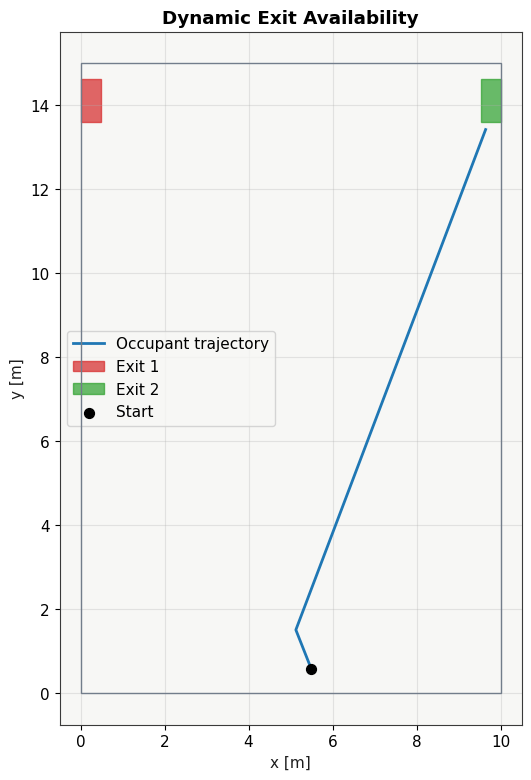

In [7]:
walkable_area = pedpy.WalkableArea(scenario.walkable_polygon)
fig, ax = plt.subplots(figsize=(7, 9))
pedpy.plot_walkable_area(walkable_area=walkable_area, axes=ax)
ax.plot(
    df["x"],
    df["y"],
    color="tab:blue",
    linewidth=2,
    label="Occupant trajectory",
)
for exit_id, polygon in exit_polygons.items():
    x, y = polygon.exterior.xy
    color = "tab:red" if exit_id == EXIT_1 else "tab:green"

    ax.fill(
        x,
        y,
        color=color,
        alpha=0.7,
        label=exit_names[exit_id],
    )
ax.scatter(
    df.iloc[0]["x"],
    df.iloc[0]["y"],
    color="black",
    marker="o",
    s=50,
    label="Start",
    zorder=5,
)

ax.set_title("Dynamic Exit Availability")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()

## Acceptance

In [8]:
assert actual_exit == EXIT_2, (
    f"Expected Exit 2 to be used after Exit 1 became unavailable, "
    f"but {exit_names[actual_exit]} was used."
)
result.cleanup();